In [26]:
!pip install requests beautifulsoup4 nltk
import requests
from bs4 import BeautifulSoup
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import re

def index_words(soup):
    index = {}
    words = re.findall(r'\w+', soup.get_text())
    for word in words:
        word = word.lower()
        if word in index:
            index[word] += 1
        else:
            index[word] = 1
    return index

In [29]:
def fetch_page(url):
  response = requests.get(url)
  if response.status_code == 200:
    soup = BeautifulSoup(response.text, 'html.parser')
    return soup
  else:
    return None

In [30]:
def remove_stop_words(index):
    stop_words = {'a', 'an', 'the', 'and', 'or',     				'in', 'on', 'at'}
    for stop_word in stop_words:
        if stop_word in index:
            del index[stop_word]
    return index

In [31]:
from nltk.stem import PorterStemmer

def apply_stemming(index):
    stemmer = PorterStemmer()
    stemmed_index = {}
    for word, count in index.items():
        stemmed_word = stemmer.stem(word)
        if stemmed_word in stemmed_index:
            stemmed_index[stemmed_word] += count
        else:
            stemmed_index[stemmed_word] = count
    return stemmed_index


In [32]:
def search(query, index):
    stemmer = PorterStemmer()
    query_words = re.findall(r'\w+', query.lower())
    results = {}

    for word in query_words:
        word = stemmer.stem(word)

        if word in index:
            results[word] = index[word]

    return results

In [33]:
def search_engine(url, query):
    soup = fetch_page(url)
    if soup is None:
        return None
    index = index_words(soup)
    index = remove_stop_words(index)
    index = apply_stemming(index)
    results = search(query, index)
    return results

In [34]:
URL = "https://www.epicgardening.com/common-garden-diseases/"
query = "type disease stem cure garden infect water fungus plant grow"
search_engine(URL, query)

{'type': 13,
 'diseas': 47,
 'stem': 4,
 'cure': 5,
 'garden': 56,
 'infect': 48,
 'water': 25,
 'fungu': 12,
 'plant': 97,
 'grow': 12}

In [36]:
import firebase_admin
from firebase_admin import credentials

cred = credentials.Certificate("/content/drive/My Drive/Ex5/serviceAccountKey.json")
# if firebase is already intialized:
if not firebase_admin._apps:
    firebase_admin.initialize_app(cred)
else:
    firebase_admin.delete_app(firebase_admin.get_app())
    firebase_admin.initialize_app(cred)


In [ ]:
!pip install firebase-admin

In [37]:
import firebase_admin
from firebase_admin import credentials, firestore, db

DB_URL = 'https://cloud-course-9c4ad-default-rtdb.europe-west1.firebasedatabase.app/'

# Initialize Firebase Admin SDK
if not firebase_admin._apps:
    cred = credentials.Certificate('/content/drive/My Drive/Ex5/serviceAccountKey.json')
    firebase_admin.initialize_app(cred, {
        'databaseURL': DB_URL
    })
else:
    pass

db_firestore = firestore.client()
db_realtime = db.reference(url=DB_URL)

print("Firebase initialized. Firestore client and Realtime Database reference created.")

Firebase initialized. Firestore client and Realtime Database reference created.


## Save results to database

In [38]:
current_results = search_engine(URL, query) # Re-run

try:
    # save to RTDB
    new_entry_ref = db_realtime.child('search_results').push() # unique id for new query
    new_entry_ref.set({
        'url': URL,
        'query': query,
        'results': current_results
    })
    print(f"Results saved to Realtime Database with key: {new_entry_ref.key}")

except Exception as e:
    print(f"Error saving to Realtime Database: {e}")

Results saved to Realtime Database with key: -Orm9Onh3hpWLmGDM-22


In [43]:
# fetch all search results
all_results = db_realtime.child('search_results').get()

if all_results:
    # Get the latest entry (Realtime DB returns a dict of push IDs)
    # We sort by the keys which are chronological push IDs
    latest_key = sorted(all_results.keys())[-1]
    latest_data = all_results[latest_key]

    firebase_results = latest_data.get('results', {})
    print(f"Successfully retrieved results for query: {latest_data.get('query')}")

    # Display the results
    display(firebase_results)
else:
    print("No results found in Firebase.")

Successfully retrieved results for query: type disease stem cure garden infect water fungus plant grow


{'cure': 5,
 'diseas': 47,
 'fungu': 12,
 'garden': 56,
 'grow': 12,
 'infect': 48,
 'plant': 97,
 'stem': 4,
 'type': 13,
 'water': 25}

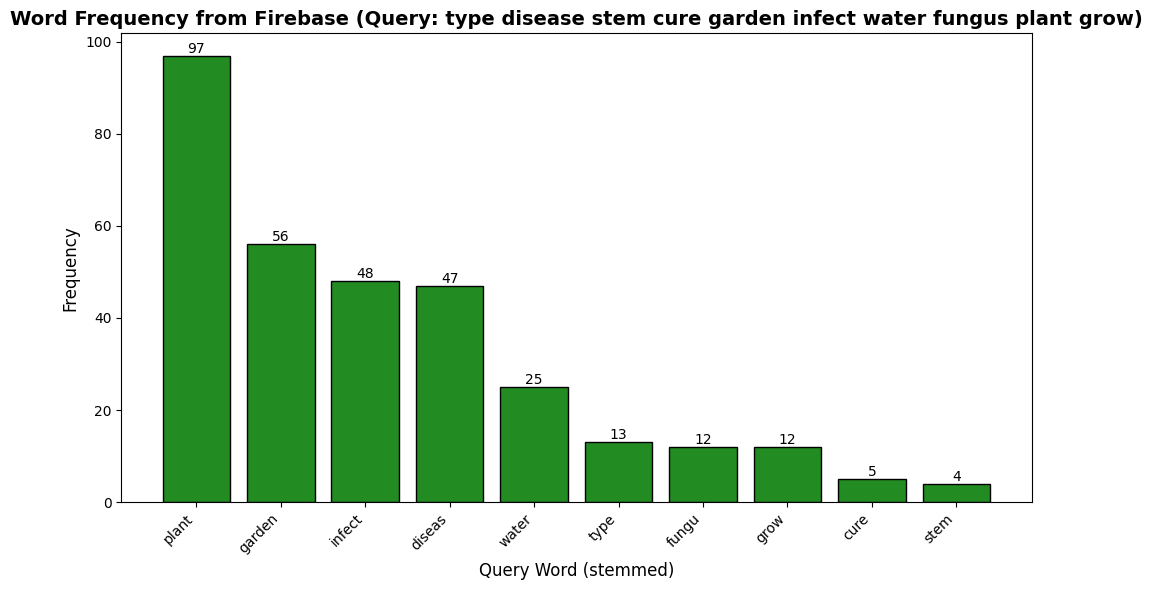

In [42]:
import matplotlib.pyplot as plt

# Ensure we have data to plot
if 'firebase_results' in locals() and firebase_results:
    # Sort by frequency - descending
    sorted_results = sorted(firebase_results.items(), key=lambda x: x[1], reverse=True)
    words, counts = zip(*sorted_results)

    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(words, counts, color='forestgreen', edgecolor='black')
    plt.title(f"Word Frequency from Firebase (Query: {latest_data.get('query')})", fontsize=14, fontweight='bold')
    plt.xlabel('Query Word (stemmed)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # Add value labels
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(count), ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot. Please run the fetch cell above.")